<a href="https://colab.research.google.com/github/shahankit82/assignment-01-2511694/blob/main/part4-vector-db/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install sentence-transformers seaborn matplotlib

In [3]:
from sentence_transformers import SentenceTransformer, util

# 10 simple sentences across 3 topics
sentences = [
    "The batsman hit a huge six.",
    "Spin bowlers turn the ball.",
    "The umpire gave him out lbw.",
    "Chop the onions finely.",
    "Add salt to the boiling water.",
    "Bake the cake for 30 minutes.",
    "Use a strong password.",
    "Beware of phishing links.",
    "Encrypt your private files.",
    "Update your software to fix bugs."
]

# Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Create the embeddings
embeddings = model.encode(sentences)
print("Embeddings created successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings created successfully!


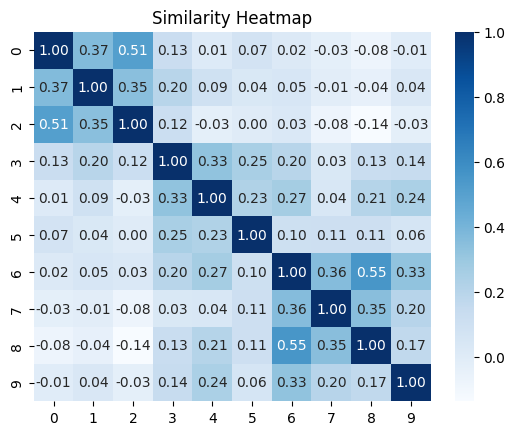

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the 10x10 similarity matrix
similarity_matrix = util.cos_sim(embeddings, embeddings)

# Draw a simple heatmap
sns.heatmap(similarity_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Similarity Heatmap")
plt.show()

In [5]:
# The new query
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query)

# Calculate similarity between the query and all 10 sentences
scores = util.cos_sim(query_embedding, embeddings)[0]

# Combine scores and sentences into a simple list
results = []
for i in range(len(sentences)):
    # .item() converts the score to a standard python number
    results.append((scores[i].item(), sentences[i]))

# Sort the list from highest score to lowest score
results.sort(reverse=True)

# Print the top 2 results
print(f"Query: {query}\n")

print("1.", results[0][1])
print("   Score:", round(results[0][0], 4))

print("\n2.", results[1][1])
print("   Score:", round(results[1][0], 4))

Query: The bowler took three wickets in one over

1. Spin bowlers turn the ball.
   Score: 0.5815

2. The batsman hit a huge six.
   Score: 0.5562
